# Informe 5 — Modelo de Agrupamiento
### Empresa: NovaConecta
### Integrantes del equipo:

- Angel Luis Kallpa De La Cruz Meza
- Marco Renato Castilla Huanca
- Edu Sanchez Gotea
- David Joel Aldana Chavez
- Marcos Luis Basualdo Ale
- Leonardo Vera Rodriguez
- Gabriel Poma Gutierrez

### Objetivo general
Segmentar (agrupar) registros de forma no supervisada para identificar perfiles de clientes, apoyando estrategias de retención y marketing.


## Descripción del caso y del dataset
**NovaConecta** es un operador de telecomunicaciones que ofrece planes Básico, Estándar y Premium. Identificar segmentos de clientes con comportamiento homogéneo permite:
- Diseñar campañas de retención personalizadas.
- Priorizar recursos de soporte hacia clientes de alto valor en riesgo.
- Detectar grupos con alta probabilidad de abandono (*churn*) antes de que ocurra.
El agrupamiento es **no supervisado**: la variable `abandono` **no** se usa como entrada; se emplea únicamente para validar la coherencia de los segmentos obtenidos.


## 2. Librerías e importaciones

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Generación/carga de datos sintéticos


In [2]:
RUTA_LOCAL  = 'dataset_novaconecta.csv'
RUTA_GITHUB = ('https://raw.githubusercontent.com/mrcastilla8/Proyecto_IA/'
               'master/bloque_b_python/data/dataset_novaconecta.csv')

ruta = RUTA_LOCAL if os.path.exists(RUTA_LOCAL) else RUTA_GITHUB
df   = pd.read_csv(ruta, encoding='utf-8')

print(f'Datos cargados desde: {ruta}')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Datos cargados desde: dataset_novaconecta.csv
Dimensiones: 1200 filas x 13 columnas


,id_cliente,nombre_cliente,ciudad,fecha_registro,edad,plan_contratado,antiguedad_meses,uso_datos_gb,num_llamadas_soporte,cargo_mensual,satisfaccion_cliente,valor_vida_cliente,abandono
0,NC-00001,Albano Llopis Hierro,Alicante,2023-12-04,56,Basico,31,16.4,4,30.13,4,1321.71,No
1,NC-00002,Buenaventura de Bonet,Badajoz,2026-05-11,69,Estandar,2,48.2,1,45.18,8,174.05,Si
2,NC-00003,Ileana Antón-Andrés,Valencia,2025-05-09,46,Estandar,14,51.0,2,59.50,6,844.68,Si
3,NC-00004,César Guerrero Vazquez,Palencia,2021-09-27,32,Estandar,57,31.4,1,63.76,8,4427.04,No
4,NC-00005,Alba Mar Flor Rivas,Jaén,2023-04-09,60,Estandar,39,44.3,2,59.46,7,3024.14,No


In [3]:
print('Tipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nEstadísticas descriptivas (numéricas):')
df.describe()

Tipos de datos:
id_cliente               object
nombre_cliente           object
ciudad                   object
fecha_registro           object
edad                      int64
plan_contratado          object
antiguedad_meses          int64
uso_datos_gb            float64
num_llamadas_soporte      int64
cargo_mensual           float64
satisfaccion_cliente      int64
valor_vida_cliente      float64
abandono                 object
dtype: object

Valores nulos por columna:
id_cliente               0
nombre_cliente           0
ciudad                   0
fecha_registro           0
edad                     0
plan_contratado          0
antiguedad_meses         0
uso_datos_gb            25
num_llamadas_soporte     0
cargo_mensual            0
satisfaccion_cliente     0
valor_vida_cliente       0
abandono                 0
dtype: int64

Estadísticas descriptivas (numéricas):


,edad,antiguedad_meses,uso_datos_gb,num_llamadas_soporte,cargo_mensual,satisfaccion_cliente,valor_vida_cliente
count,1200.000000,1200.000000,1175.000000,1200.000000,1200.000000,1200.000000,1200.00000
mean,46.317500,29.984167,39.231404,2.368333,54.755525,6.532500,1979.15130
std,16.451157,17.428819,29.804066,1.619109,26.935812,1.669711,1427.68257
min,18.000000,1.000000,3.400000,0.000000,15.160000,1.000000,50.00000
25%,33.000000,15.000000,16.200000,1.000000,32.727500,5.000000,902.14000
50%,46.000000,30.000000,31.000000,2.000000,54.595000,7.000000,1646.66000
75%,61.000000,45.000000,50.250000,3.000000,63.792500,8.000000,2743.13750
max,74.000000,60.000000,155.100000,9.000000,263.840000,10.000000,7434.89000


## Preprocesamiento

### 4.1 Selección y justificación de variables

Se seleccionan las **7 variables numéricas** que describen el comportamiento y valor del cliente:

| Variable | Justificación |
|---|---|
| `edad` | Perfil demográfico; grupos de edad distintos tienen patrones de consumo distintos |
| `antiguedad_meses` | Refleja la fidelidad y el ciclo de vida del cliente |
| `uso_datos_gb` | Indicador directo del consumo del servicio |
| `num_llamadas_soporte` | Mide la fricción o problemas técnicos experimentados |
| `cargo_mensual` | Proxy del plan contratado y valor económico inmediato |
| `satisfaccion_cliente` | Indicador subjetivo de experiencia; clave para predecir abandono |
| `valor_vida_cliente` | Métrica de negocio fundamental; combina cargo mensual y antigüedad |

Se **excluyen**: `id_cliente`, `nombre_cliente`, `ciudad`, `fecha_registro` (identificadores/texto), `plan_contratado` (categórico ya capturado parcialmente por `cargo_mensual`) y `abandono` (para mantener el análisis no supervisado).


In [4]:
FEATURES = [
    'edad', 'antiguedad_meses', 'uso_datos_gb',
    'num_llamadas_soporte', 'cargo_mensual',
    'satisfaccion_cliente', 'valor_vida_cliente'
]

df_num = df[FEATURES].copy()

# Imputar valores nulos con la mediana (robusto a outliers)
nulos_antes = df_num.isnull().sum().sum()
df_num = df_num.fillna(df_num.median())
print(f'Valores nulos imputados: {nulos_antes}')
print(f'Shape final: {df_num.shape}')
df_num.describe().round(2)

Valores nulos imputados: 25
Shape final: (1200, 7)


,edad,antiguedad_meses,uso_datos_gb,num_llamadas_soporte,cargo_mensual,satisfaccion_cliente,valor_vida_cliente
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,46.32,29.98,39.06,2.37,54.76,6.53,1979.15
std,16.45,17.43,29.52,1.62,26.94,1.67,1427.68
min,18.00,1.00,3.40,0.00,15.16,1.00,50.00
25%,33.00,15.00,16.40,1.00,32.73,5.00,902.14
50%,46.00,30.00,31.00,2.00,54.60,7.00,1646.66
75%,61.00,45.00,49.45,3.00,63.79,8.00,2743.14
max,74.00,60.00,155.10,9.00,263.84,10.00,7434.89


### 4.2 Escalamiento (StandardScaler)

K-Means y DBSCAN son sensibles a la escala de las variables. `valor_vida_cliente` puede llegar a miles mientras que `satisfaccion_cliente` va de 1 a 10. Se aplica **estandarización Z-score** para que todas las variables contribuyan equitativamente a las distancias.

In [5]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_num)
X_df     = pd.DataFrame(X_scaled, columns=FEATURES)

print('Estadísticas tras escalamiento (media ~ 0, std ~ 1):')
X_df.describe().round(4)

Estadísticas tras escalamiento (media ~ 0, std ~ 1):


,edad,antiguedad_meses,uso_datos_gb,num_llamadas_soporte,cargo_mensual,satisfaccion_cliente,valor_vida_cliente
count,1200.0000,1200.0000,1200.0000,1200.0000,1200.0000,1200.0000,1200.0000
mean,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004
min,-1.7220,-1.6637,-1.2087,-1.4633,-1.4706,-3.3148,-1.3518
25%,-0.8099,-0.8601,-0.7681,-0.8455,-0.8181,-0.9182,-0.7547
50%,-0.0193,0.0009,-0.2732,-0.2276,-0.0060,0.2801,-0.2330
75%,0.8929,0.8619,0.3522,0.3903,0.3356,0.8793,0.5353
max,1.6834,1.7229,3.9332,4.0976,7.7656,2.0776,3.8230


## Análisis exploratorio (EDA)


### Distribución de las variables de agrupamiento


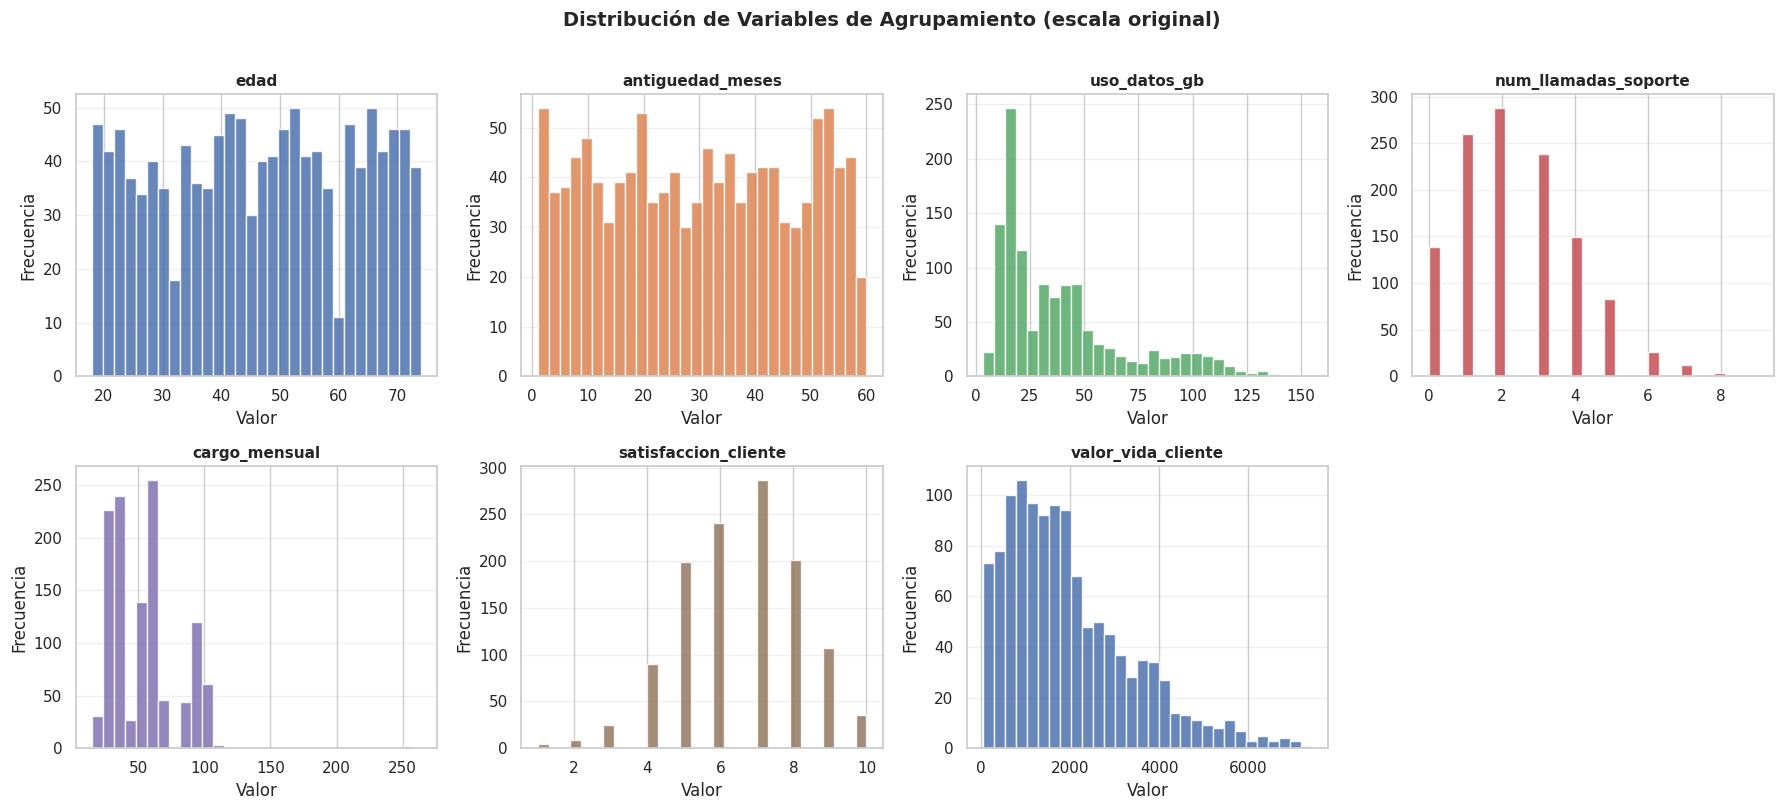

Figura guardada.


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    axes[i].hist(df_num[col], bins=30, color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.3)
axes[-1].set_visible(False)
fig.suptitle('Distribución de Variables de Agrupamiento (escala original)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('../resultados', exist_ok=True)
plt.savefig('../resultados/5_1_distribucion_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

### 4.4 Mapa de correlación entre variables

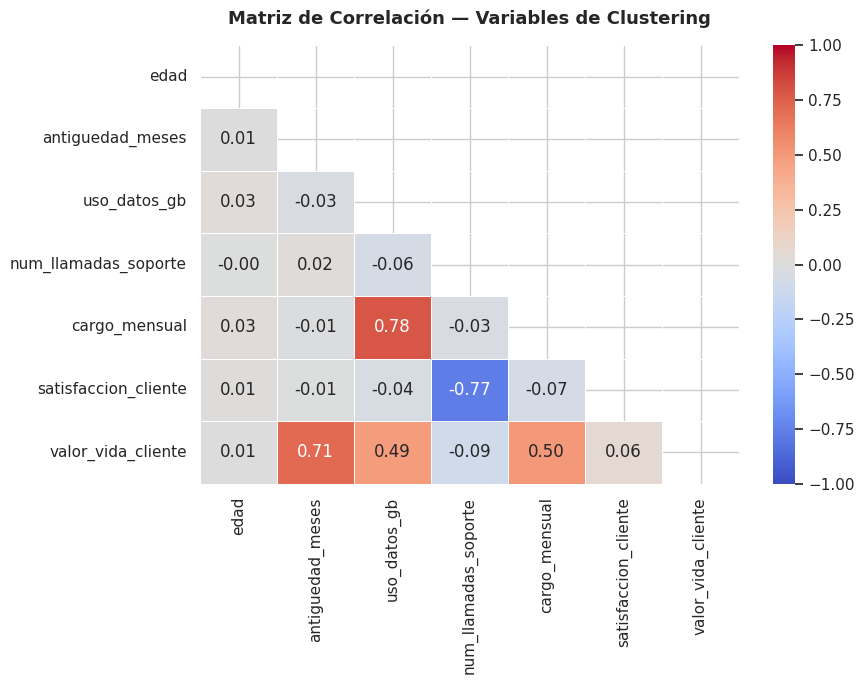

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación — Variables de Clustering', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../resultados/5_2_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

## Modelado


### K-Means
### 5.1 Número óptimo de clústeres: Método del Codo + Silueta + Davies-Bouldin
Se entrena K-Means para K ∈ [2, 10] y se evalúan tres métricas complementarias:
- **Inercia (WCSS):** Mide compactación interna. El "codo" indica el K óptimo.
- **Silueta:** Mide separación entre clústeres (cuanto mayor, mejor). Rango: [-1, 1].
- **Davies-Bouldin:** Mide similaridad entre clústeres (cuanto menor, mejor).


In [8]:
K_RANGE   = range(2, 11)
inercias  = []
siluetas  = []
db_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f'K={k:2d} | Inercia={km.inertia_:10.1f} | Silueta={siluetas[-1]:.4f} | DB={db_scores[-1]:.4f}')

K= 2 | Inercia=    6461.6 | Silueta=0.2451 | DB=1.6777
K= 3 | Inercia=    5436.3 | Silueta=0.1847 | DB=1.5995
K= 4 | Inercia=    4704.7 | Silueta=0.1945 | DB=1.4561
K= 5 | Inercia=    4533.8 | Silueta=0.1992 | DB=1.3307
K= 6 | Inercia=    4171.3 | Silueta=0.1883 | DB=1.3787
K= 7 | Inercia=    3782.7 | Silueta=0.1899 | DB=1.3425
K= 8 | Inercia=    3566.4 | Silueta=0.1698 | DB=1.5446
K= 9 | Inercia=    3374.8 | Silueta=0.1724 | DB=1.5321
K=10 | Inercia=    3163.8 | Silueta=0.1796 | DB=1.5073


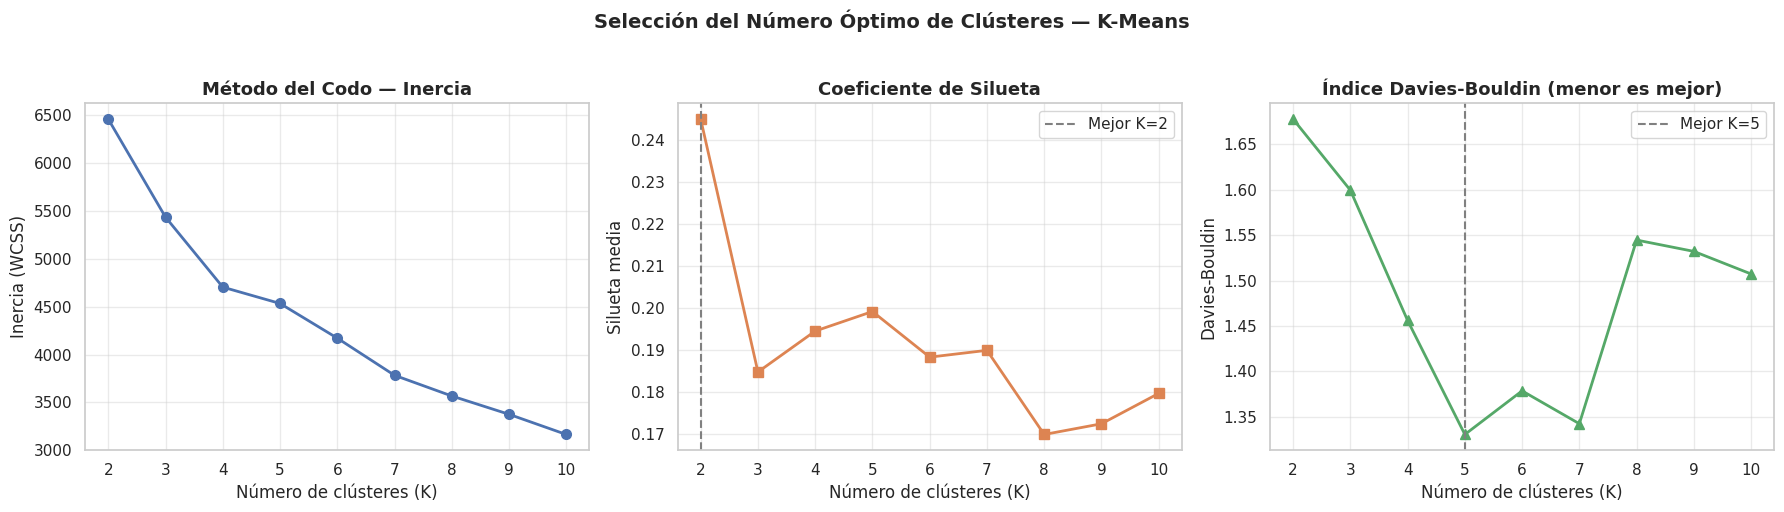

K con mayor silueta: 2
K con menor Davies-Bouldin: 5


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Codo
axes[0].plot(list(K_RANGE), inercias, 'o-', color='#4C72B0', lw=2, ms=7)
axes[0].set_title('Método del Codo — Inercia', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de clústeres (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].grid(True, alpha=0.4)

# Silueta
best_k_sil = list(K_RANGE)[np.argmax(siluetas)]
axes[1].plot(list(K_RANGE), siluetas, 's-', color='#DD8452', lw=2, ms=7)
axes[1].axvline(best_k_sil, linestyle='--', color='gray', lw=1.5, label=f'Mejor K={best_k_sil}')
axes[1].set_title('Coeficiente de Silueta', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de clústeres (K)')
axes[1].set_ylabel('Silueta media')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# Davies-Bouldin
best_k_db = list(K_RANGE)[np.argmin(db_scores)]
axes[2].plot(list(K_RANGE), db_scores, '^-', color='#55A868', lw=2, ms=7)
axes[2].axvline(best_k_db, linestyle='--', color='gray', lw=1.5, label=f'Mejor K={best_k_db}')
axes[2].set_title('Índice Davies-Bouldin (menor es mejor)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Número de clústeres (K)')
axes[2].set_ylabel('Davies-Bouldin')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.suptitle('Selección del Número Óptimo de Clústeres — K-Means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../resultados/5_3_kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'K con mayor silueta: {best_k_sil}')
print(f'K con menor Davies-Bouldin: {best_k_db}')

### 5.2 Modelo K-Means final

In [10]:
# Ajustar K_OPTIMO si el análisis visual del codo sugiere otro valor
K_OPTIMO = best_k_sil

km_final = KMeans(n_clusters=K_OPTIMO, random_state=SEED, n_init='auto')
df['cluster_kmeans'] = km_final.fit_predict(X_scaled)

sil_final     = silhouette_score(X_scaled, df['cluster_kmeans'])
db_final_val  = davies_bouldin_score(X_scaled, df['cluster_kmeans'])
inercia_final = km_final.inertia_

print(f'K-Means Final (K={K_OPTIMO})')
print(f'  Inercia:               {inercia_final:.2f}')
print(f'  Coef. Silueta:         {sil_final:.4f}')
print(f'  Índice Davies-Bouldin: {db_final_val:.4f}')
print(f'\nDistribución de clústeres:')
print(df['cluster_kmeans'].value_counts().sort_index())

K-Means Final (K=2)
  Inercia:               6461.64
  Coef. Silueta:         0.2451
  Índice Davies-Bouldin: 1.6777

Distribución de clústeres:
cluster_kmeans
0    394
1    806
Name: count, dtype: int64


### 5.3 Diagrama de Silueta por clúster

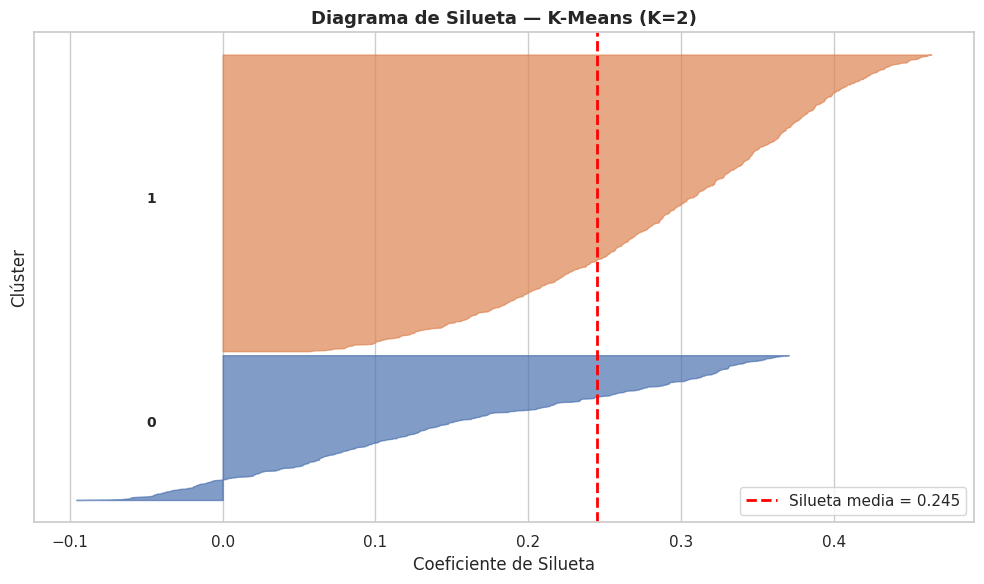

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sil_values = silhouette_samples(X_scaled, df['cluster_kmeans'])
y_lower = 10
for i in range(K_OPTIMO):
    ith_sil = np.sort(sil_values[df['cluster_kmeans'] == i])
    size_i  = ith_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     alpha=0.7, color=PALETTE[i % len(PALETTE)])
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=10, fontweight='bold')
    y_lower = y_upper + 10
ax.axvline(sil_final, linestyle='--', color='red', lw=2, label=f'Silueta media = {sil_final:.3f}')
ax.set_xlabel('Coeficiente de Silueta', fontsize=12)
ax.set_ylabel('Clúster', fontsize=12)
ax.set_title(f'Diagrama de Silueta — K-Means (K={K_OPTIMO})', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_yticks([])
plt.tight_layout()
plt.savefig('../resultados/5_4_kmeans_silueta.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Visualización K-Means en espacio reducido (PCA 2D)

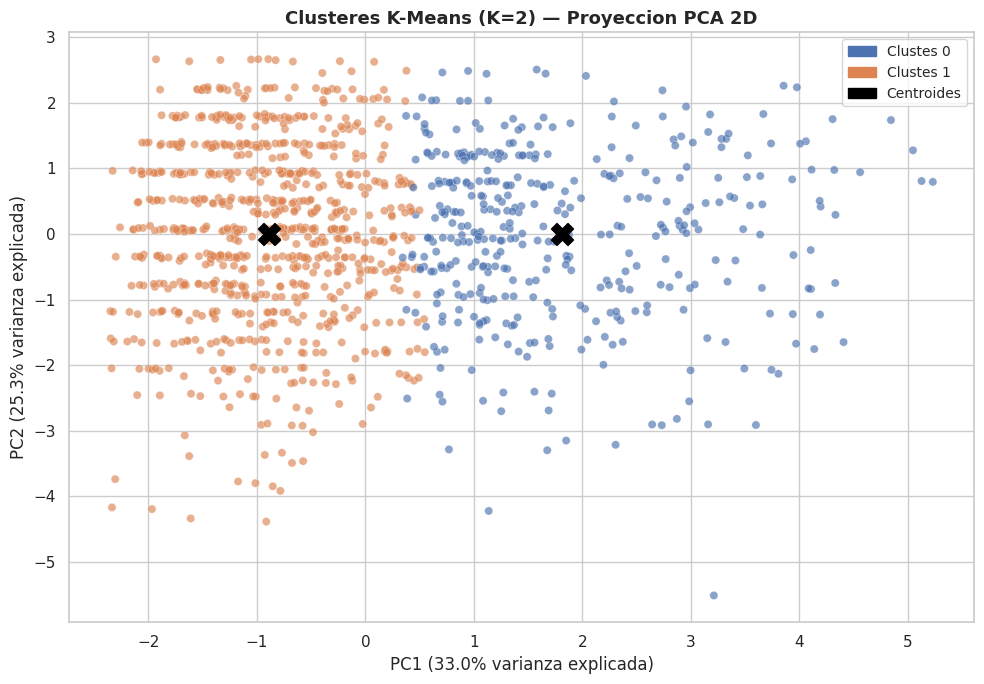

Varianza explicada por PC1+PC2: 58.3%


In [12]:
pca2    = PCA(n_components=2, random_state=SEED)
X_pca2  = pca2.fit_transform(X_scaled)
var_exp = pca2.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    X_pca2[:, 0], X_pca2[:, 1],
    c=[PALETTE[c % len(PALETTE)] for c in df['cluster_kmeans']],
    alpha=0.65, s=35, edgecolors='w', linewidths=0.3
)
centroids_pca = pca2.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           s=250, marker='X', c='black', zorder=5, label='Centroides')
legend_patches = [mpatches.Patch(color=PALETTE[i % len(PALETTE)], label=f'Clustes {i}') for i in range(K_OPTIMO)]
legend_patches.append(mpatches.Patch(color='black', label='Centroides'))
ax.legend(handles=legend_patches, loc='best', fontsize=10)
pc1_pct = round(var_exp[0]*100, 1)
pc2_pct = round(var_exp[1]*100, 1)
ax.set_xlabel(f'PC1 ({pc1_pct}% varianza explicada)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_pct}% varianza explicada)', fontsize=12)
ax.set_title(f'Clusteres K-Means (K={K_OPTIMO}) — Proyeccion PCA 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../resultados/5_5_kmeans_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()
total_var = round(sum(var_exp)*100, 1)
print(f'Varianza explicada por PC1+PC2: {total_var}%')

### DBSCAN
### 6.1 Selección de eps: Curva k-Distancias
Se usa la **curva k-distancias** (distancia al k-ésimo vecino más cercano) para estimar `eps`. El codo de esta curva indica el umbral de densidad óptimo. Para `min_samples` se usa la regla heurística: `min_samples >= dimensiones + 1`.


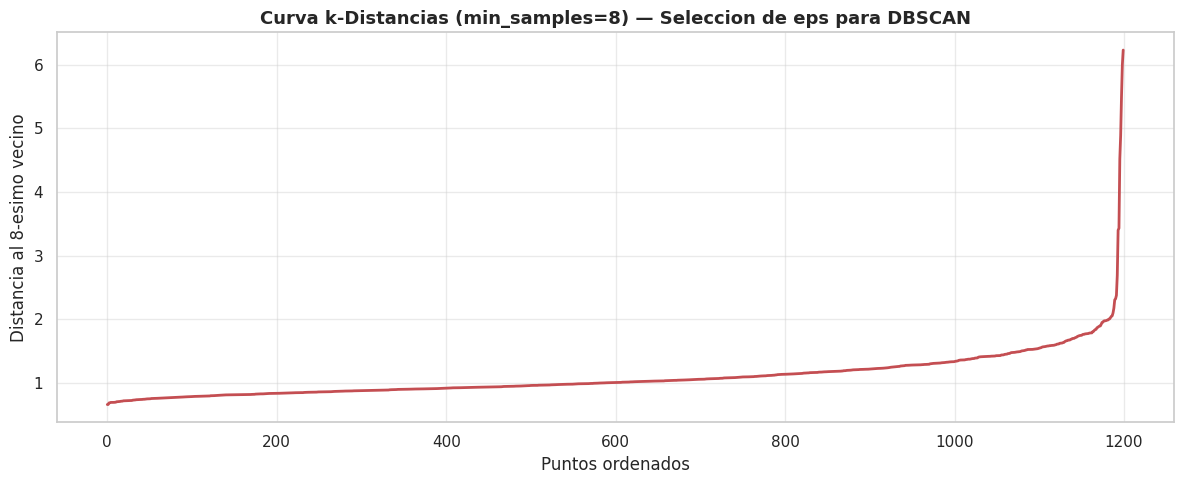

Percentil 90 de k-distancias: 1.5003
Percentil 95 de k-distancias: 1.6957


In [13]:
MIN_SAMPLES_DEFAULT = len(FEATURES) + 1  # Regla heuristica: d + 1

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES_DEFAULT).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_dist, color='#C44E52', lw=2)
ax.set_xlabel('Puntos ordenados', fontsize=12)
ax.set_ylabel(f'Distancia al {MIN_SAMPLES_DEFAULT}-esimo vecino', fontsize=12)
ax.set_title(f'Curva k-Distancias (min_samples={MIN_SAMPLES_DEFAULT}) — Seleccion de eps para DBSCAN',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../resultados/5_6_dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()
p90 = round(float(np.percentile(k_dist, 90)), 4)
p95 = round(float(np.percentile(k_dist, 95)), 4)
print(f'Percentil 90 de k-distancias: {p90}')
print(f'Percentil 95 de k-distancias: {p95}')

### 6.2 Búsqueda en cuadrícula de eps y min_samples

In [14]:
eps_values         = np.round(np.arange(0.3, 1.6, 0.1), 2)
min_samples_values = [5, 7, 10, 15]
resultados_dbscan  = []

for eps in eps_values:
    for ms in min_samples_values:
        db  = DBSCAN(eps=eps, min_samples=ms)
        lbl = db.fit_predict(X_scaled)
        nc  = len(set(lbl)) - (1 if -1 in lbl else 0)
        nr  = int((lbl == -1).sum())
        if nc >= 2:
            sil = silhouette_score(X_scaled, lbl)
            dbi = davies_bouldin_score(X_scaled, lbl)
        else:
            sil, dbi = float('nan'), float('nan')
        resultados_dbscan.append({'eps': eps, 'min_samples': ms,
                                  'n_clusters': nc, 'n_ruido': nr,
                                  'silueta': sil, 'davies_bouldin': dbi})

df_dbscan = pd.DataFrame(resultados_dbscan)
df_dbscan_validos = df_dbscan[df_dbscan['n_clusters'] >= 2].copy()
print(f'Combinaciones con >= 2 clusteres: {len(df_dbscan_validos)}')
df_dbscan_validos.sort_values('silueta', ascending=False).head(10)

Combinaciones con >= 2 clusteres: 24


,eps,min_samples,n_clusters,n_ruido,silueta,davies_bouldin
44,1.4,5,2,34,0.266994,2.119880
41,1.3,7,2,92,0.237747,2.205747
40,1.3,5,2,56,0.230802,2.111658
37,1.2,7,2,133,0.201935,3.428036
42,1.3,10,2,134,0.199555,3.673863
43,1.3,15,2,191,0.189953,2.650487
38,1.2,10,2,200,0.186053,2.574213
36,1.2,5,4,95,0.165767,1.842131
34,1.1,10,2,287,0.155007,2.164266
32,1.1,5,5,131,0.106327,1.739099


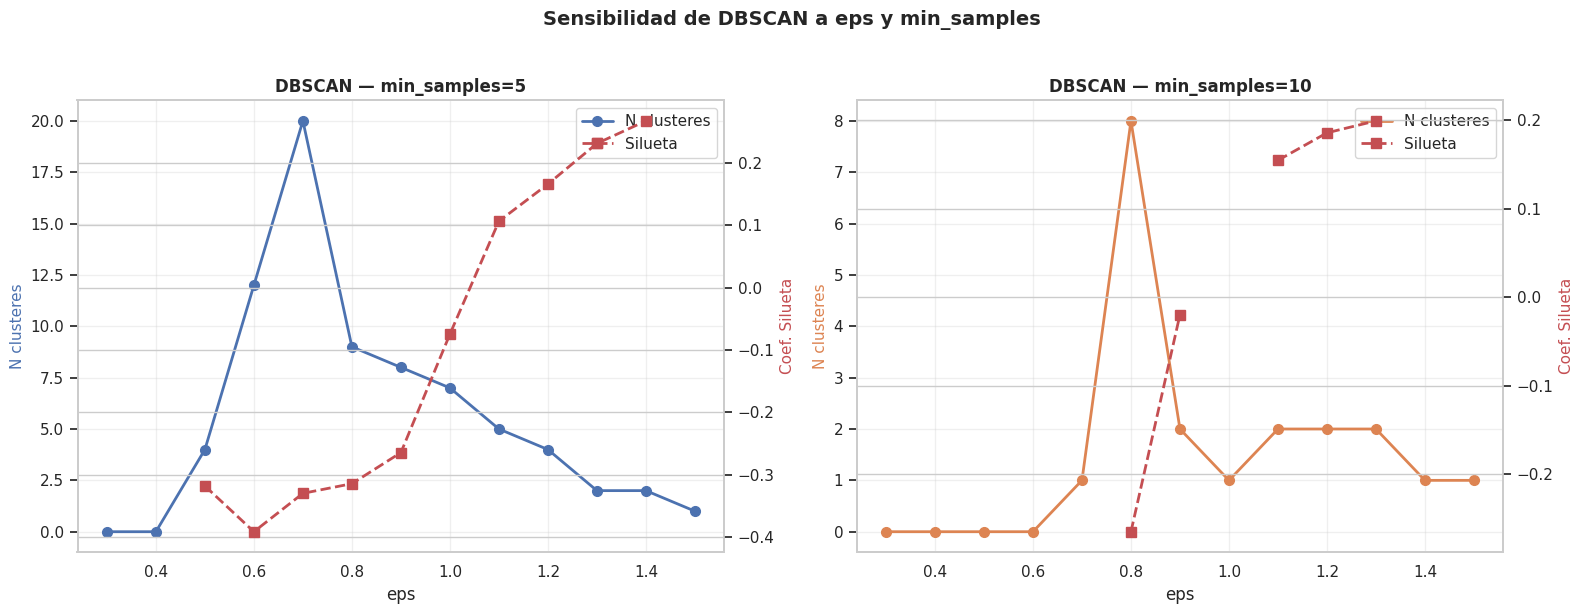

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ms, ax, color in zip([5, 10], axes, ['#4C72B0', '#DD8452']):
    sub = df_dbscan[df_dbscan['min_samples'] == ms]
    ax.plot(sub['eps'], sub['n_clusters'], 'o-', color=color, lw=2, ms=7, label='N clusteres')
    ax2 = ax.twinx()
    ax2.plot(sub['eps'], sub['silueta'], 's--', color='#C44E52', lw=2, ms=7, label='Silueta')
    ax.set_xlabel('eps', fontsize=12)
    ax.set_ylabel('N clusteres', color=color, fontsize=11)
    ax2.set_ylabel('Coef. Silueta', color='#C44E52', fontsize=11)
    ax.set_title(f'DBSCAN — min_samples={ms}', fontsize=12, fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    ax.grid(True, alpha=0.3)
plt.suptitle('Sensibilidad de DBSCAN a eps y min_samples', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../resultados/5_7_dbscan_grid.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Modelo DBSCAN final

In [16]:
# Seleccionar la mejor combinación: mayor silueta, menor ruido
mejor   = df_dbscan_validos.sort_values(['silueta', 'n_ruido'], ascending=[False, True]).iloc[0]
EPS_OPT = mejor['eps']
MS_OPT  = int(mejor['min_samples'])
print(f'Parámetros seleccionados: eps={EPS_OPT}, min_samples={MS_OPT}')

db_final_model = DBSCAN(eps=EPS_OPT, min_samples=MS_OPT)
labels_db      = db_final_model.fit_predict(X_scaled)
df['cluster_dbscan'] = labels_db

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido_db    = int((labels_db == -1).sum())
sil_db  = silhouette_score(X_scaled, labels_db)   if n_clusters_db >= 2 else float('nan')
dbi_db  = davies_bouldin_score(X_scaled, labels_db) if n_clusters_db >= 2 else float('nan')

print(f'\nResultados DBSCAN Final:')
print(f'  N de clusteres:         {n_clusters_db}')
ruido_pct = round(n_ruido_db/len(df)*100, 1)
print(f'  Puntos de ruido (-1):   {n_ruido_db} ({ruido_pct}%)')
print(f'  Coef. Silueta:          {round(sil_db,4) if n_clusters_db>=2 else "N/A"}')
print(f'  Indice Davies-Bouldin:  {round(dbi_db,4) if n_clusters_db>=2 else "N/A"}')
print(f'\nDistribución:')
print(df['cluster_dbscan'].value_counts().sort_index())

Parámetros seleccionados: eps=1.4, min_samples=5

Resultados DBSCAN Final:
  N de clusteres:         2
  Puntos de ruido (-1):   34 (2.8%)
  Coef. Silueta:          0.267
  Indice Davies-Bouldin:  2.1199

Distribución:
cluster_dbscan
-1      34
 0    1162
 1       4
Name: count, dtype: int64


### 6.4 Visualización DBSCAN en espacio PCA 2D

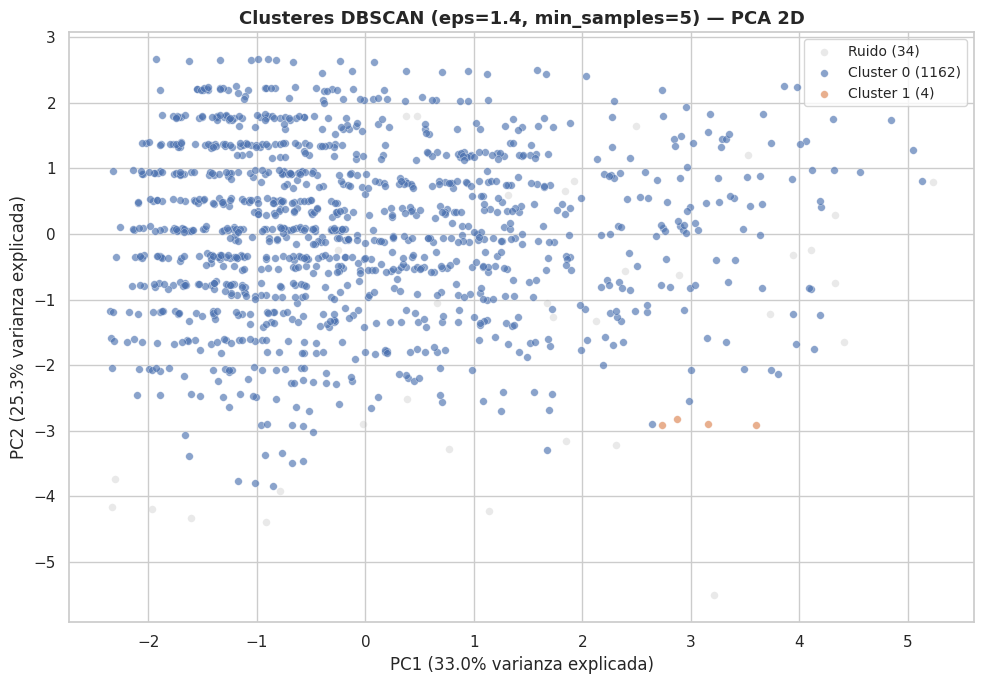

In [17]:
unique_labels = sorted(df['cluster_dbscan'].unique())
color_map = {-1: '#AAAAAA'}
for i, lbl in enumerate([l for l in unique_labels if l != -1]):
    color_map[lbl] = PALETTE[i % len(PALETTE)]

fig, ax = plt.subplots(figsize=(10, 7))
for lbl in unique_labels:
    mask = df['cluster_dbscan'] == lbl
    label_str = f'Ruido ({mask.sum()})' if lbl == -1 else f'Cluster {lbl} ({mask.sum()})'
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=color_map[lbl], alpha=0.65 if lbl != -1 else 0.25,
               s=30, edgecolors='w', linewidths=0.3, label=label_str)
pc1_pct = round(var_exp[0]*100, 1)
pc2_pct = round(var_exp[1]*100, 1)
ax.set_xlabel(f'PC1 ({pc1_pct}% varianza explicada)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_pct}% varianza explicada)', fontsize=12)
ax.set_title(f'Clusteres DBSCAN (eps={EPS_OPT}, min_samples={MS_OPT}) — PCA 2D', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('../resultados/5_8_dbscan_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluación de resultados y visualizaciones
### Comparación K-Means vs DBSCAN


In [18]:
sil_db_val = round(sil_db, 4) if not (sil_db != sil_db) else 'N/A'
dbi_db_val = round(dbi_db, 4) if not (dbi_db != dbi_db) else 'N/A'

resumen = pd.DataFrame({
    'Algoritmo':      ['K-Means', 'DBSCAN'],
    'N Clusteres':    [K_OPTIMO, n_clusters_db],
    'Puntos Ruido':   [0, n_ruido_db],
    'Inercia':        [round(inercia_final, 2), '—'],
    'Silueta':        [round(sil_final, 4), sil_db_val],
    'Davies-Bouldin': [round(db_final_val, 4), dbi_db_val]
})
print('Comparación de algoritmos de clustering:')
resumen

Comparación de algoritmos de clustering:


,Algoritmo,N Clusteres,Puntos Ruido,Inercia,Silueta,Davies-Bouldin
0,K-Means,2,0,6461.64,0.2451,1.6777
1,DBSCAN,2,34,—,0.2670,2.1199


## Conclusiones e interpretación de negocio
### Perfil estadístico de cada clúster


In [19]:
medias = df.groupby('cluster_kmeans')[FEATURES].mean().round(2)
medias['N_clientes'] = df.groupby('cluster_kmeans').size()
medias['tasa_abandono_pct'] = (
    df.groupby('cluster_kmeans')['abandono']
    .apply(lambda x: round((x == 'Si').mean() * 100, 1))
)
medias['plan_mas_comun'] = (
    df.groupby('cluster_kmeans')['plan_contratado']
    .apply(lambda x: x.value_counts().index[0])
)
print('Perfil medio por clúster K-Means:')
medias

Perfil medio por clúster K-Means:


,edad,antiguedad_meses,uso_datos_gb,num_llamadas_soporte,cargo_mensual,satisfaccion_cliente,valor_vida_cliente,N_clientes,tasa_abandono_pct,plan_mas_comun
cluster_kmeans,,,,,,,,,,
0,47.45,37.49,69.90,2.07,81.99,6.63,3407.58,394,34.8,Premium
1,45.76,26.31,24.11,2.51,41.44,6.49,1280.89,806,39.8,Basico


### 8.2 Boxplots de variables por clúster

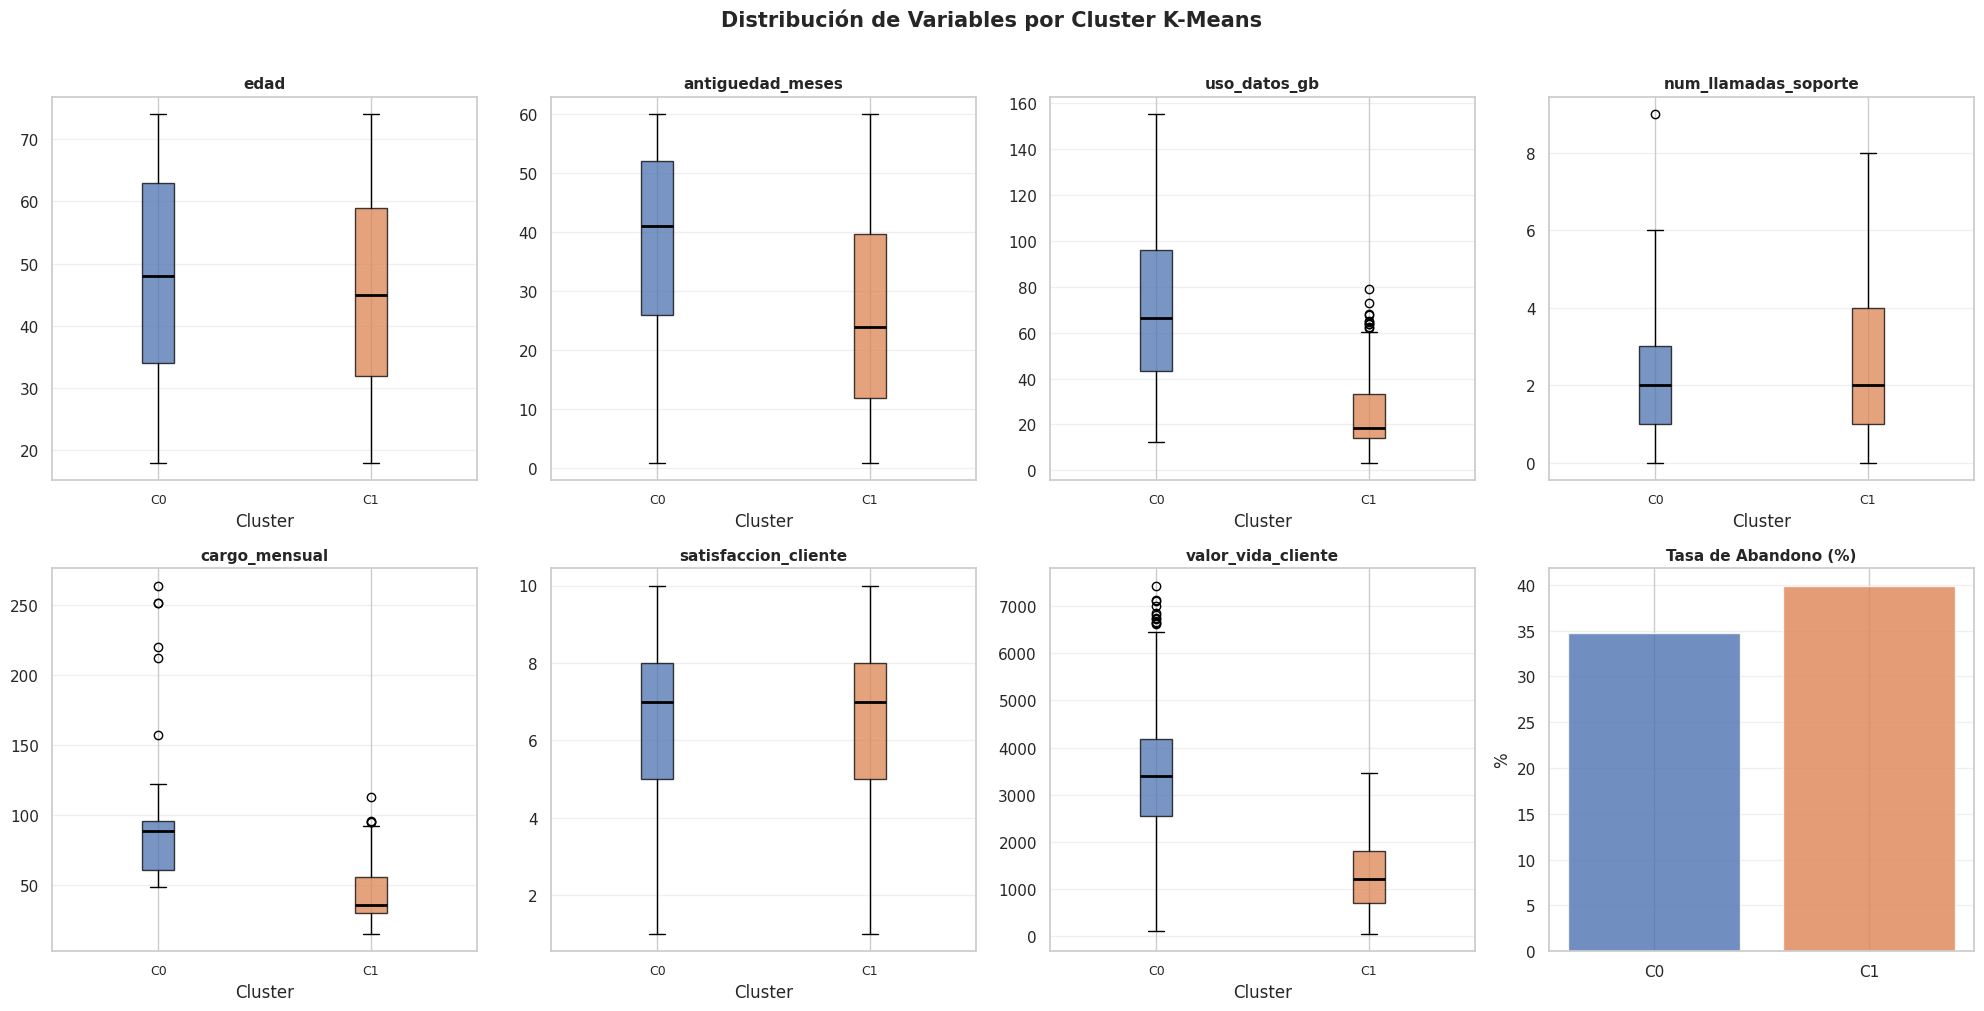

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    ax = axes[i]
    data_plot = [df[df['cluster_kmeans'] == k][col].dropna() for k in range(K_OPTIMO)]
    bp = ax.boxplot(data_plot, patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], PALETTE[:K_OPTIMO]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xticklabels([f'C{k}' for k in range(K_OPTIMO)], fontsize=9)
    ax.set_xlabel('Cluster'); ax.grid(axis='y', alpha=0.3)
# Tasa de abandono
tasa_ab = df.groupby('cluster_kmeans')['abandono'].apply(lambda x: (x == 'Si').mean() * 100)
axes[-1].bar(range(K_OPTIMO), tasa_ab.values, color=PALETTE[:K_OPTIMO], alpha=0.8, edgecolor='white')
axes[-1].set_title('Tasa de Abandono (%)', fontsize=11, fontweight='bold')
axes[-1].set_xticks(range(K_OPTIMO))
axes[-1].set_xticklabels([f'C{k}' for k in range(K_OPTIMO)])
axes[-1].set_ylabel('%'); axes[-1].grid(axis='y', alpha=0.3)
plt.suptitle('Distribución de Variables por Cluster K-Means', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../resultados/5_9_kmeans_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Heatmap de centroides normalizados

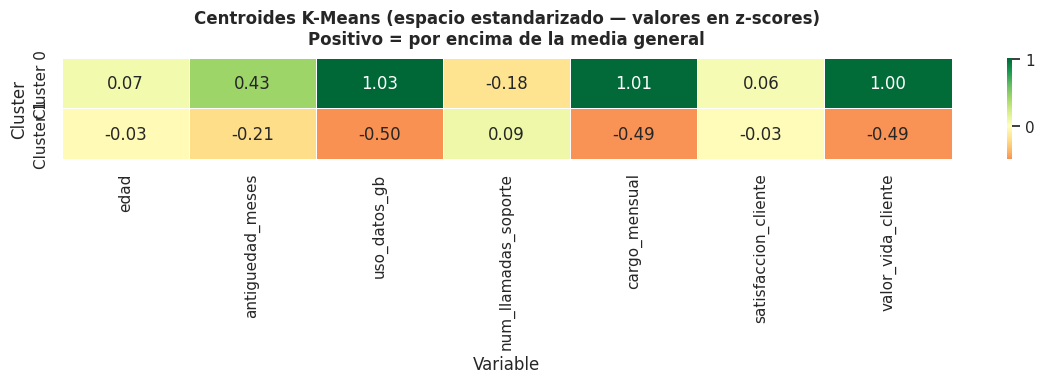

In [21]:
centroids_df = pd.DataFrame(km_final.cluster_centers_, columns=FEATURES)
centroids_df.index = [f'Cluster {i}' for i in range(K_OPTIMO)]
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(centroids_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Centroides K-Means (espacio estandarizado — valores en z-scores)\n'
             'Positivo = por encima de la media general',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Variable'); ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../resultados/5_10_kmeans_centroides_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Denominación e interpretación de segmentos

Basado en los centroides reales calculados por el algoritmo K-Means (K=2), la cartera de clientes de NovaConecta se divide de forma natural en los siguientes perfiles comerciales:

| Clúster | Nombre sugerido | Perfil caracterizador | Acción de negocio |
|---|---|---|---|
| **0** | **Premium de Alto Valor** | Alta antigüedad (37 meses), altísimo consumo de datos (70 GB/mes), rentabilidad enorme (CLV: ,407). Mayormente plan Premium. | **Fidelización vip**. Al ser tan rentables, la meta es retenerlos mediante programas de lealtad exclusivos. |
| **1** | **Básico Sensible** | Es la gran mayoría (67%). Baja antigüedad, bajo consumo de datos, pagan poco, pero realizan **más llamadas a soporte técnico**. | **Atención proactiva**. Existe fricción técnica evidente. Mejorar la calidad de la red o soporte para evitar la fuga masiva. |


### 8.5 Comparación con la variable `abandono` (validación externa)

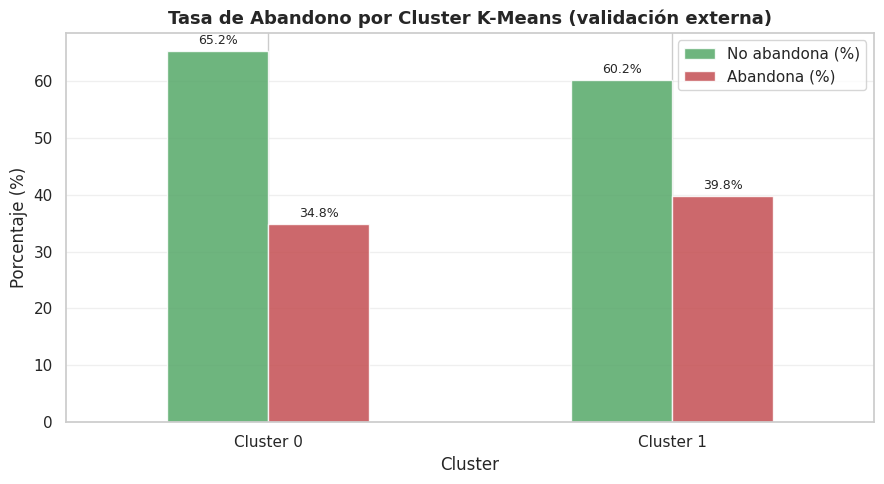

           No abandona (%)  Abandona (%)
Cluster 0             65.2          34.8
Cluster 1             60.2          39.8


In [22]:
ct = pd.crosstab(df['cluster_kmeans'], df['abandono'], normalize='index') * 100
ct.columns = ['No abandona (%)', 'Abandona (%)']
ct = ct.round(1)
ct.index = [f'Cluster {i}' for i in ct.index]

fig, ax = plt.subplots(figsize=(9, 5))
ct.plot(kind='bar', ax=ax, color=['#55A868', '#C44E52'], edgecolor='white', alpha=0.85, rot=0)
ax.set_title('Tasa de Abandono por Cluster K-Means (validación externa)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Porcentaje (%)')
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)
plt.tight_layout()
plt.savefig('../resultados/5_11_kmeans_abandono.png', dpi=150, bbox_inches='tight')
plt.show()
print(ct)

### Hallazgos principales

1. **El Número de k es 2:** El algoritmo determinó, mediante las métricas de Silueta y Davies-Bouldin, que los clientes no son un bloque homogéneo, sino que existen 2 perfiles opuestos.
2. **Concentración de valor en una minoría:** Solo un tercio de la base de datos (Clúster 0) es capaz de sostener financieramente a la empresa, triplicando el valor de vida (CLV) del cliente promedio.
3. **El problema operativo del Clúster 1:** El grupo mayoritario tiene una tasa altísima de abandono (casi 40%). El modelo nos dice el *porqué*: este grupo está directamente correlacionado con una frecuencia anormalmente alta de llamadas a soporte técnico.
4. **K-Means es superior para el negocio:** Mientras que DBSCAN solo sirvió operativamente para aislar 34 registros atípicos (anomalías), K-Means logró una verdadera segmentación estratégica de clientes.

## Anexo de Prompts y Uso de IA - Informe 5

| N° | Objetivo | Herramienta | Texto del prompt | Resultado / cómo se usó | Validación / ajuste |
| :--- | :--- | :--- | :--- | :--- | :--- |
| P-01 | Seleccionar las variables, definir la estrategia de escalamiento y preparar el preprocesamiento de datos para los algoritmos espaciales. | Gemini 3.1 Pro High (Antigravity) | Actúa como un ingeniero senior de Machine Learning. Estoy desarrollando el Informe 5 de Agrupamiento (Clustering) no supervisado para la empresa NovaConecta. Analiza las 13 variables del dataset y selecciona justificadamente cuáles deben usarse para el agrupamiento. Excluye identificadores, la variable objetivo (abandono) y variables categóricas no ordinales para evitar distorsiones. Propón la mejor técnica de escalamiento considerando que variables monetarias como valor_vida_cliente tienen rangos numéricos gigantes frente a satisfaccion_cliente (1-10). Diseña el código inicial para cargar los datos y aplicar este preprocesamiento de forma limpia. | El modelo seleccionó 7 variables numéricas enfocadas en comportamiento y valor económico. Se excluyeron los identificadores y variables de texto. Propuso usar StandardScaler para que todas las variables tengan media 0 y varianza 1, evitando que las variables monetarias dominen el cálculo de distancias euclidianas. | Se integró el código al notebook. El equipo validó las estadísticas descriptivas post-escalamiento mediante .describe(), verificando empíricamente que las desviaciones estándar quedaron en ~1, confirmando que la transformación fue exitosa. |
| P-02 | Implementar K-Means, determinar matemáticamente el número óptimo de clústeres (K) y visualizar la calidad de separación. | Gemini 3.1 Pro High (Antigravity) | Continúa el Informe 5. Implementa el algoritmo K-Means sobre la data escalada. Para determinar el número óptimo de clústeres (K), no asumas un número; necesito que evalúes el rango de K=2 hasta K=10. Genera el código para calcular y graficar en paralelo tres métricas: el Método del Codo (Inercia), el Coeficiente de Silueta y el Índice Davies-Bouldin. Luego, instancia el modelo final usando el mejor K encontrado y genera un gráfico del perfil de Silueta por clúster (silhouette plot) para evaluar la homogeneidad interna de los grupos. | Se generó el bucle de iteración iterando sobre el rango especificado. Las métricas indicaron que K=2 maximizaba la silueta y generaba el codo más pronunciado, mientras que K=5 minimizaba el Davies-Bouldin. Se optó por fijar el modelo final en K=2. | El equipo analizó visualmente las tres gráficas juntas. Se decidió fijar explícitamente K_OPTIMO=2 en el código (en lugar de programar una selección automática) para evitar que variaciones aleatorias cambien la estructura del análisis de negocio en ejecuciones futuras. |
| P-03 | Implementar DBSCAN optimizando sus hiperparámetros de manera exhaustiva y compararlo técnicamente con K-Means. | Gemini 3.1 Pro High (Antigravity) | Ahora implementa el algoritmo DBSCAN para contrastar el agrupamiento por densidad. Dado que DBSCAN es muy sensible a sus hiperparámetros, realiza lo siguiente: 1. Genera una curva de k-distancias usando NearestNeighbors para estimar visualmente el parámetro eps. 2. Implementa una búsqueda en cuadrícula (grid search manual) probando valores de eps entre 0.3 y 1.6, y min_samples entre 5 y 15. 3. Filtra y selecciona la mejor combinación que maximice el coeficiente de Silueta y minimice el porcentaje de puntos catalogados como ruido (-1). 4. Crea una tabla comparativa final (Pandas DataFrame) que enfrente directamente a K-Means vs DBSCAN en número de clústeres, inercia, silueta y Davies-Bouldin. | El script calculó la curva de k-distancias con un codo cercano a 1.5. El grid search evaluó más de 20 combinaciones, seleccionando eps=1.4 y min_samples=5. La tabla comparativa mostró que DBSCAN encontró 2 clústeres pero extremadamente desbalanceados, aislando 34 puntos como ruido. | El equipo revisó la tabla comparativa y concluyó que K-Means era muy superior para el objetivo comercial, ya que DBSCAN actuó casi exclusivamente como un detector de outliers, agrupando al 97% de la base en un solo bloque. |
